# US Equities Panel: Model-Based Features

Every feature in [`03_financial_features`](03_financial_features.ipynb) is a function of
past bars: hand it a row's history and it returns the same value whatever else the panel
contains. A feature on this page is a function of *parameters estimated from* bars, so the
estimation window is part of what the feature knows, and a parameter fitted once on the
whole sample carries the whole sample into every row it touches - including the rows a
model will later be scored on. That is the hazard this stage exists to show, and the
discipline that removes it is to refit inside every walk-forward fold on that fold's
training bars alone.

Three fitted transforms are built that way:

1. **Wasserstein regime distance**: k-means on overlapping windows of the cross-sectional
   median return under the one-dimensional Wasserstein distance. Centroids come from the
   training window; the assignment runs forward over training and validation.
2. **Fractional differencing**: FFD on log prices and log volume per stock. The weights are
   a deterministic function of the differencing order, so nothing is estimated and the
   transform is identical in every fold. Section 3 measures what the order chosen here
   costs in stationarity and buys in memory, rather than asserting the trade.
3. **GARCH(1,1)** conditional volatility, fitted on the most liquid stocks of each training
   window with a market-level fit standing in for the rest. Parameters come from the
   training bars; `model.fix()` runs the variance recursion forward over validation without
   re-estimating them, so the volatility a row carries is filtered rather than smoothed.

## Learning objectives

- Separate the two windows a fitted feature has - the one its parameters come from and the
  one it is evaluated over - and keep the first inside the fold
- Read a per-fold parameter path as evidence about refit cadence rather than as noise
- Measure a stationarity-versus-memory trade instead of quoting the default that encodes it
- Score an incremental IC on validation rows, in time order, with the autocorrelation and
  multiplicity corrections separated

## Book reference, prerequisites and artifacts

Chapter 9, Sections 9.1 (Stationarity), 9.3 (Volatility), 9.5 (Regimes). Reads the adjusted
daily panel through `load_us_equities()`, `config/setup.yaml` for the fold design and the
holdout boundary, and the primary label file written by [`02_labels`](02_labels.ipynb) for
the incremental IC in Section 7. Writes `features/model_based.parquet` and its digest
sidecar, which the model stages join to the stage-03 matrix on `(symbol, timestamp, fold)`.

In [1]:
"""US Equities Panel: Temporal Features."""

import warnings
from dataclasses import dataclass
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from numpy.typing import NDArray

warnings.filterwarnings("ignore")

from arch import arch_model
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.engineer.features.fdiff import ffdiff, get_ffd_weights
from statsmodels.tsa.stattools import adfuller

from case_studies.utils.artifact_digest import read_digest, value_digest, write_artifact
from data import load_us_equities
from utils.artifact_specs import resolve_label_horizon
from utils.cv_splits import generate_cv_splits
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

CASE_DIR = get_case_study_dir("us_equities_panel")
FEATURES_DIR = CASE_DIR / "features"

# The eligibility screen, carried by 02_labels and 03_financial_features from the same three
# constants on the same columns, so all three stages screen one universe.
MIN_ADV_USD = 1_000_000
MIN_PRICE = 5.0
ADV_WINDOW = 21

# Transform parameters. These define the transforms rather than the strategy, so they are
# declared here; everything that defines the strategy is bound from setup.yaml below.
FFD_D = 0.4  # equity-class default; Section 3 measures what it costs and buys
FFD_D_GRID = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
FFD_THRESHOLD = 1e-5

WASSERSTEIN_WINDOW = 21
WASSERSTEIN_OVERLAP = 5
N_CLUSTERS = 2  # risk-on vs risk-off

GARCH_TOP_N = 200
GARCH_MIN_OBS = 504

FDR_ALPHA = 0.05

FloatArray = NDArray[np.float64]
IntArray = NDArray[np.int64]

In [2]:
CASE_STUDY_ID = "us_equities_panel"
START_DATE = "1990-01-01"
MAX_FOLDS = 0  # 0 = all folds; papermill injects 2 for CI

## Configuration

The fold design, the holdout boundary and the primary label come from `config/setup.yaml`.
The label's horizon is what binds Section 7: an IC series scored on a one-session forward
return needs its Newey-West lag set from that horizon, and the validation window it may be
scored over ends one session before the holdout opens rather than on the holdout date.

In [3]:
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_HORIZON = int(resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, SETUP).rstrip("Dd"))
LABEL_BUFFER = SETUP["labels"]["buffer"]
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
END_DATE = str(SETUP["evaluation"]["holdout_end"])

print(f"Primary label {PRIMARY_LABEL} over {LABEL_HORIZON} session(s), buffer {LABEL_BUFFER}")
print(f"Holdout opens {HOLDOUT_START}, panel ends {END_DATE}")
print(
    f"Screen: printed close over ${MIN_PRICE:.0f}, {ADV_WINDOW}-session ADV over ${MIN_ADV_USD:,}"
)

Primary label fwd_ret_1d over 1 session(s), buffer 1D
Holdout opens 2016-01-01, panel ends 2018-03-31
Screen: printed close over $5, 21-session ADV over $1,000,000


## Why Regime Detection for Momentum?

Momentum strategies are vulnerable to sharp reversals at regime
transitions -- "momentum crashes" (Daniel and Moskowitz 2016). The
temporal features below detect these transitions: Wasserstein regime
distance flags shifts in market central tendency, GARCH captures
volatility clustering, and FFD preserves the long-memory structure
in price levels that standard differencing would destroy.

## 1. Load Data

The same eligibility screen as [`02_labels`](02_labels.ipynb) and
[`03_financial_features`](03_financial_features.ipynb), rebuilt from the same three
constants on the same columns: a printed close above \$5, and dollar volume
`close * volume` averaging above \$1M over the previous month. Both legs read figures the
tape carried on the day, so neither depends on a corporate action that had not happened
yet, and Section B of [`02_labels`](02_labels.ipynb) derives why the adjusted close cannot
serve for either.

**The screen is declared here and applied after the per-symbol transforms**, exactly as
[`03_financial_features`](03_financial_features.ipynb) Section 6 argues. Fractional
differencing and a GARCH recursion both read a stock's series in order and count rows; on
the screened frame they would count *eligible* rows, so a stock that falls below a
threshold for two years and recovers would have its FFD window and its variance recursion
reach straight across the excursion as if it were consecutive sessions. Both run on the
complete series, and the eligible frame decides only which rows are emitted.

The digest of the panel read here has to equal the one
[`02_labels`](02_labels.ipynb) recorded against the label file this notebook scores
against in Section 7; the assertion below is what makes the two files comparable rather
than merely both present.

In [4]:
raw_df = load_us_equities(start_date=START_DATE, end_date=END_DATE)

# Normalize types
if raw_df.schema["timestamp"] == pl.Datetime:
    raw_df = raw_df.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))

raw_df = raw_df.sort(["symbol", "timestamp"])

MARKET_DATA_DIGEST = value_digest(raw_df, ["symbol", "timestamp", "close", "volume", "adj_close"])
LABEL_INPUT_DIGEST = read_digest(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")["inputs"][
    "market_data"
]
print(f"market_data digest: {MARKET_DATA_DIGEST}")
assert MARKET_DATA_DIGEST == LABEL_INPUT_DIGEST, (
    f"the labels were written against market_data {LABEL_INPUT_DIGEST} and this stage read "
    f"{MARKET_DATA_DIGEST}. Re-run 02_labels before scoring features against its output."
)

# Compute base columns on the complete series
raw_df = raw_df.with_columns(
    (pl.col("adj_close") / pl.col("adj_close").shift(1).over("symbol") - 1).alias("returns"),
    (pl.col("close") * pl.col("volume")).alias("dollar_volume"),
)
raw_df = raw_df.with_columns(
    pl.col("dollar_volume").rolling_mean(ADV_WINDOW).over("symbol").alias("adv_21d")
)

ELIGIBLE = (pl.col("close") > MIN_PRICE) & (pl.col("adv_21d") > MIN_ADV_USD)
df = raw_df.filter(ELIGIBLE)

print(f"Loaded {len(raw_df):,} rows, {raw_df['symbol'].n_unique()} symbols")
print(f"Eligible: {len(df):,} rows, {df['symbol'].n_unique()} symbols")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

market_data digest: 81db7d7920165013


Loaded 14,498,930 rows, 3199 symbols
Eligible: 9,984,970 rows, 3178 symbols
Date range: 1990-01-30 to 2018-03-27


## 1b. The fold contract

The folds are resolved here, before any model runs, because every fit below is defined
relative to them and a transform that resolves its own boundaries afterwards has nothing
to be checked against. They come from one route - `generate_cv_splits` reading the
`evaluation` block of `config/setup.yaml` - with the label buffer bound from the same file.

A holdout fold is appended and its features **are** emitted: the transforms here are
unsupervised, they read prices and never labels, so a parameter set estimated entirely
before `holdout_start` may be run forward to produce filtered values *for* holdout dates.
The model stages need those rows to score the holdout once. What may not happen is a fit
that reads a holdout bar, and the assertion below is what rules that out.

In [5]:
holdout_start = HOLDOUT_START
holdout_end = END_DATE

splits = generate_cv_splits(df, case_study_id=CASE_STUDY_ID, label_buffer=LABEL_BUFFER)
n_cv_folds = len(splits)

# Build list of folds: CV folds + holdout fold
folds = []
for s in splits:
    folds.append(
        {
            "fold": s["fold"],
            "is_holdout": False,
            "train_start": str(s["train_start"])[:10],
            "train_end": str(s["train_end"])[:10],
            "test_start": str(s["val_start"])[:10],
            "test_end": str(s["val_end"])[:10],
        }
    )

# Holdout fold: fit on everything before the boundary, emit through the end of the panel.
# The CV folds each carry the rolling ten-year window `setup.yaml` declares; the holdout
# fold is deliberately given the whole pre-holdout sample instead, because it is fitted once
# and there is no later fold whose comparability a shorter window would preserve.
last_cv_train_start = folds[-1]["train_start"] if folds else str(df["timestamp"].min())
folds.append(
    {
        "fold": n_cv_folds,
        "is_holdout": True,
        "train_start": last_cv_train_start,
        "train_end": holdout_start,
        "test_start": holdout_start,
        "test_end": holdout_end,
    }
)

if MAX_FOLDS > 0:
    # Keep first MAX_FOLDS CV folds + holdout
    cv_folds = [f for f in folds if not f["is_holdout"]][:MAX_FOLDS]
    holdout_folds = [f for f in folds if f["is_holdout"]]
    folds = cv_folds + holdout_folds

print(f"Walk-Forward Folds ({len(folds)} total, {n_cv_folds} CV + 1 holdout):")
for f in folds:
    tag = " [HOLDOUT]" if f.get("is_holdout", False) else ""
    print(
        f"  Fold {f['fold']}{tag}: train [{f['train_start']} to {f['train_end']}) "
        f"test [{f['test_start']} to {f['test_end']})"
    )

# Every training window ends at or before the holdout boundary. This is the one condition
# the whole stage rests on, and it is asserted rather than described: a fold whose training
# span crept past the boundary would still produce features and still print a fold table.
for f in folds:
    assert f["train_end"] <= holdout_start, (
        f"fold {f['fold']} fits parameters on bars through {f['train_end']}, which is inside "
        f"the holdout opening {holdout_start}"
    )
# Only the holdout fold emits rows dated at or after the boundary.
for f in folds:
    if not f["is_holdout"]:
        assert f["test_end"] <= holdout_start, (
            f"CV fold {f['fold']} emits rows through {f['test_end']}, past {holdout_start}"
        )
print(f"  every training window ends at or before {holdout_start}")

Walk-Forward Folds (17 total, 16 CV + 1 holdout):
  Fold 0: train [2005-01-14 to 2014-12-30) test [2015-01-02 to 2015-12-30)
  Fold 1: train [2004-01-15 to 2014-01-02) test [2014-01-06 to 2014-12-31)
  Fold 2: train [2003-01-15 to 2013-01-02) test [2013-01-04 to 2014-01-03)
  Fold 3: train [2002-01-15 to 2012-01-03) test [2012-01-05 to 2013-01-03)
  Fold 4: train [2001-01-10 to 2011-01-03) test [2011-01-05 to 2012-01-04)
  Fold 5: train [2000-01-11 to 2010-01-04) test [2010-01-06 to 2011-01-04)
  Fold 6: train [1999-01-12 to 2009-01-02) test [2009-01-06 to 2010-01-05)
  Fold 7: train [1998-01-12 to 2008-01-03) test [2008-01-07 to 2009-01-05)
  Fold 8: train [1997-01-13 to 2007-01-03) test [2007-01-05 to 2008-01-04)
  Fold 9: train [1996-01-15 to 2005-12-30) test [2006-01-04 to 2007-01-04)
  Fold 10: train [1995-01-16 to 2004-12-31) test [2005-01-04 to 2006-01-03)
  Fold 11: train [1994-01-14 to 2003-12-31) test [2004-01-05 to 2005-01-03)
  Fold 12: train [1993-01-18 to 2002-12-31) test

The figure is the fold contract itself. Each row is one fold: the shaded bar is the span
the parameters come from, the open bar is the span they are run forward over, and the rule
is the holdout boundary. What the reader should be able to see is that no shaded bar
crosses the rule, and that the only bar of any kind to the right of it belongs to the
holdout fold.

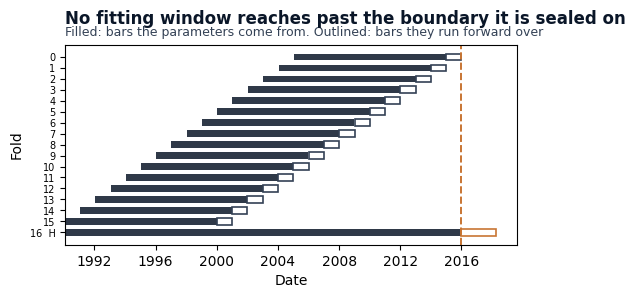

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
_hold = date.fromisoformat(holdout_start)
for row, f in enumerate(folds):
    tr0, tr1 = date.fromisoformat(f["train_start"]), date.fromisoformat(f["train_end"])
    te0, te1 = date.fromisoformat(f["test_start"]), date.fromisoformat(f["test_end"])
    ax.barh(row, (tr1 - tr0).days, left=tr0, height=0.62, color=COLORS["blue"], alpha=0.85)
    ax.barh(
        row,
        (te1 - te0).days,
        left=te0,
        height=0.62,
        facecolor="none",
        edgecolor=COLORS["copper"] if f["is_holdout"] else COLORS["neutral"],
        linewidth=1.2,
    )
ax.axvline(_hold, color=COLORS["copper"], ls="--", lw=1.4)
ax.set_yticks(range(len(folds)))
ax.set_yticklabels([f"{f['fold']}{'  H' if f['is_holdout'] else ''}" for f in folds], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Date")
ax.set_ylabel("Fold")
add_message_title(
    ax,
    "No fitting window reaches past the boundary it is sealed on",
    subtitle="Filled: bars the parameters come from. Outlined: bars they run forward over",
)
plt.show()

## 2. Wasserstein Regime Distance

Regime shifts in market central tendency are detected by clustering windowed sequences of
the cross-sectional median return. At each date the median return is taken across every
eligible stock trading that day - the count is printed below, and it is a fraction of the
symbols the panel holds over the whole sample, because most of them were not listed or not
tradable on any given date. That scalar series is how the market's centre of mass moves.
Wasserstein k-means then clusters overlapping windows of it into $k=2$ regimes (risk-on
versus risk-off), treating each window as an empirical measure.

**What this captures**: Shifts in the *central tendency* of cross-sectional
returns over time. This is distinct from modeling the full distributional
shape (tails, skewness, bimodality), which would require quantile vectors
or the full cross-sectional distribution as input. The cross-sectional
std, skew, and tail quantiles are computed for diagnostics but not used
in clustering.

**Walk-forward approach**: For each CV fold, fit centroids on the training
window only, then assign regime labels for the full train+test period.
Since this is a market-level feature, all stocks share the same regime
signal at each date.

In [7]:
@dataclass(frozen=True)
class LiftedStream:
    """Overlapping windows of cross-sectional return distributions."""

    segments: FloatArray  # (n_segments, window_len)
    sorted_segments: FloatArray  # Sorted per window
    starts: IntArray  # Start indices
    window_len: int
    step: int


def lift_stream(
    returns: FloatArray,
    window_len: int,
    overlap: int,
) -> LiftedStream:
    """Lift a 1D return stream into overlapping windows."""
    step = window_len - overlap
    windows_view = np.lib.stride_tricks.sliding_window_view(returns, window_shape=window_len)
    windows_view = windows_view[::step]
    segments = np.ascontiguousarray(windows_view, dtype=np.float64)
    sorted_segments = np.sort(segments, axis=1)
    starts = np.arange(0, segments.shape[0] * step, step, dtype=np.int64)

    return LiftedStream(
        segments=segments,
        sorted_segments=sorted_segments,
        starts=starts,
        window_len=window_len,
        step=step,
    )

In [8]:
def wasserstein_distance_1d(sorted_a: FloatArray, sorted_b: FloatArray, p: float = 1.0) -> float:
    """1D p-Wasserstein distance between equal-weight empirical measures."""
    diff_p = np.abs(sorted_a - sorted_b) ** p
    return float(diff_p.mean() ** (1.0 / p))


def wasserstein_barycenter_1d(sorted_members: FloatArray, p: float = 1.0) -> FloatArray:
    """Wasserstein barycenter: median (p=1) or mean (p=2) of sorted atoms."""
    if p == 1.0:
        return np.median(sorted_members, axis=0).astype(np.float64)
    return sorted_members.mean(axis=0).astype(np.float64)

In [9]:
def fit_wasserstein_kmeans(
    sorted_segments: FloatArray,
    n_clusters: int = 2,
    max_iter: int = 50,
    n_init: int = 5,
    random_state: int = 42,
) -> tuple[IntArray, FloatArray]:
    """Fit Wasserstein k-means on sorted 1D segments.

    Returns (labels, centroids).
    """
    rng = np.random.default_rng(random_state)
    n_samples = sorted_segments.shape[0]
    best_labels = None
    best_centroids = None
    best_inertia = float("inf")

    for _ in range(n_init):
        # Random initialization
        idx = rng.choice(n_samples, size=n_clusters, replace=False)
        centroids = sorted_segments[idx].copy()

        for _ in range(max_iter):
            # Assignment: compute distance to each centroid
            dists = np.zeros((n_samples, n_clusters))
            for k in range(n_clusters):
                diff = np.abs(sorted_segments - centroids[k][None, :])
                dists[:, k] = diff.mean(axis=1)

            labels = dists.argmin(axis=1)

            # Update centroids
            new_centroids = np.zeros_like(centroids)
            for k in range(n_clusters):
                members = sorted_segments[labels == k]
                if len(members) > 0:
                    new_centroids[k] = wasserstein_barycenter_1d(members, p=1.0)
                else:
                    new_centroids[k] = centroids[k]

            if np.allclose(centroids, new_centroids, atol=1e-6):
                break
            centroids = new_centroids

        inertia = sum(dists[i, labels[i]] for i in range(n_samples))
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels
            best_centroids = centroids

    return best_labels, best_centroids

### Compute Cross-Sectional Returns per Date

Compute cross-sectional return statistics at each date. Only the median is
used for Wasserstein clustering (see Section 2 narrative); the std, skew,
and tail quantiles are retained for diagnostic inspection and potential
future enrichment of the clustering input.

In [10]:
# Cross-sectional return statistics per date
xs_stats = (
    df.filter(pl.col("returns").is_not_null())
    .group_by("timestamp")
    .agg(
        pl.col("returns").median().alias("xs_median_ret"),
        pl.col("returns").std().alias("xs_std_ret"),
        pl.col("returns").skew().alias("xs_skew"),
        pl.col("returns").quantile(0.1).alias("xs_q10"),
        pl.col("returns").quantile(0.9).alias("xs_q90"),
        pl.col("returns").count().alias("n_stocks"),
    )
    .sort("timestamp")
    .filter(pl.col("n_stocks") >= 50)
)

# Use cross-sectional median return as market-level signal for clustering
market_ret = xs_stats["xs_median_ret"].to_numpy()
dates = xs_stats["timestamp"].to_list()

print(f"Cross-sectional stats: {len(xs_stats):,} dates")
if len(xs_stats) > 0:
    print(f"  Median stocks/date: {int(xs_stats['n_stocks'].median())}")

Cross-sectional stats: 7,094 dates
  Median stocks/date: 1440


### Per-Fold Wasserstein Clustering

For each fold, fit Wasserstein k-means centroids on the training window only,
then assign regime labels for the full train+test period. The reference
distribution (centroids) sees no future data relative to the fold boundary.
Since this is a market-level feature, all stocks share the same regime
signal at each date.

In [11]:
def assign_regime_features(
    market_ret: FloatArray,
    dates_list: list,
    centroids: FloatArray,
    start_idx: int,
    end_idx: int,
) -> list[dict]:
    """Assign regime labels for dates[start_idx:end_idx] given fitted centroids."""
    results = []
    for t in range(start_idx, end_idx):
        if t < WASSERSTEIN_WINDOW:
            continue

        recent_window = market_ret[t - WASSERSTEIN_WINDOW : t]
        recent_sorted = np.sort(recent_window)

        dists = [
            wasserstein_distance_1d(recent_sorted, centroids[k]) for k in range(len(centroids))
        ]

        cluster = int(np.argmin(dists))
        min_dist, max_dist = min(dists), max(dists)

        # Tail divergence: right-tail vs left-tail distance to nearest centroid
        tail_div = float(
            np.mean(np.abs(recent_sorted[-5:] - centroids[cluster][-5:]))
            - np.mean(np.abs(recent_sorted[:5] - centroids[cluster][:5]))
        )

        results.append(
            {
                "timestamp": dates_list[t],
                "wass_cluster": cluster,
                "wass_dist_min": min_dist,
                "wass_dist_max": max_dist,
                "wass_dist_ratio": min_dist / (max_dist + 1e-10),
                "wass_tail_div": tail_div,
            }
        )
    return results

In [12]:
step = WASSERSTEIN_WINDOW - WASSERSTEIN_OVERLAP
min_length = WASSERSTEIN_WINDOW + (2 * N_CLUSTERS - 1) * step

wasserstein_all_folds = []
wass_centroid_rows = []  # per-fold centroid summary, read by the stability figure

print("Computing per-fold Wasserstein features...")
print(f"  Window: {WASSERSTEIN_WINDOW}, Overlap: {WASSERSTEIN_OVERLAP}, Clusters: {N_CLUSTERS}")

for fold in folds:
    fold_idx = fold["fold"]
    train_end_date = fold["train_end"]
    test_end_date = fold["test_end"]
    train_start_date = fold["train_start"]

    # Find index boundaries in the xs_stats date array
    train_indices = [
        i for i, d in enumerate(dates) if str(d) >= train_start_date and str(d) < train_end_date
    ]
    full_indices = [
        i for i, d in enumerate(dates) if str(d) >= train_start_date and str(d) < test_end_date
    ]

    if len(train_indices) < min_length:
        print(
            f"  Fold {fold_idx}: insufficient training data ({len(train_indices)} < {min_length})"
        )
        continue

    # Fit centroids on training data only
    train_ret = market_ret[train_indices[0] : train_indices[-1] + 1]
    lifted = lift_stream(train_ret, WASSERSTEIN_WINDOW, WASSERSTEIN_OVERLAP)
    _, centroids = fit_wasserstein_kmeans(
        lifted.sorted_segments, n_clusters=N_CLUSTERS, random_state=42
    )

    # Sort centroids by mean value: cluster 0 = lower return (stress), 1 = higher (normal)
    sort_idx = np.argsort([c.mean() for c in centroids])
    centroids = centroids[sort_idx]

    wass_centroid_rows.append(
        {
            "fold": fold_idx,
            "stress_centroid_mean": float(centroids[0].mean()),
            "normal_centroid_mean": float(centroids[-1].mean()),
            "centroid_separation": float(np.abs(centroids[-1] - centroids[0]).mean()),
        }
    )

    # Assign features for the full train+test period
    fold_features = []
    if full_indices:
        fold_features = assign_regime_features(
            market_ret,
            dates,
            centroids,
            start_idx=full_indices[0],
            end_idx=full_indices[-1] + 1,
        )
        for row in fold_features:
            row["fold"] = fold_idx
        wasserstein_all_folds.extend(fold_features)

    tag = " [HOLDOUT]" if fold.get("is_holdout", False) else ""
    print(f"  Fold {fold_idx}{tag}: {len(fold_features)} dates ({len(train_indices)} train)")

wass_df = pl.DataFrame(wasserstein_all_folds) if wasserstein_all_folds else pl.DataFrame()
n_wass_folds = wass_df["fold"].n_unique() if "fold" in wass_df.columns else 0
print(f"\nWasserstein features: {len(wass_df):,} rows across {n_wass_folds} folds")
if len(wass_df) > 0:
    cluster_counts = wass_df.group_by("wass_cluster").len().sort("wass_cluster")
    for row in cluster_counts.iter_rows(named=True):
        print(f"  Cluster {row['wass_cluster']}: {row['len']:,} rows")

Computing per-fold Wasserstein features...
  Window: 21, Overlap: 5, Clusters: 2
  Fold 0: 2758 dates (2506 train)
  Fold 1: 2759 dates (2508 train)
  Fold 2: 2761 dates (2508 train)
  Fold 3: 2761 dates (2510 train)


  Fold 4: 2762 dates (2509 train)


  Fold 5: 2762 dates (2509 train)
  Fold 6: 2762 dates (2509 train)
  Fold 7: 2762 dates (2509 train)
  Fold 8: 2762 dates (2509 train)


  Fold 9: 2762 dates (2509 train)
  Fold 10: 2762 dates (2509 train)
  Fold 11: 2762 dates (2509 train)
  Fold 12: 2762 dates (2509 train)
  Fold 13: 2762 dates (2509 train)


  Fold 14: 2762 dates (2510 train)
  Fold 15: 2736 dates (2504 train)
  Fold 16 [HOLDOUT]: 7073 dates (6533 train)

Wasserstein features: 51,230 rows across 17 folds
  Cluster 0: 17,390 rows
  Cluster 1: 33,840 rows


### What the clustering inferred, on validation dates

The figure draws the quantity the feature actually carries, over the dates it would be
used on. Each fold contributes only its validation span, so what is plotted is a chain of
out-of-sample assignments from sixteen different fits rather than one fit's view of the
whole sample - which is the object a model downstream receives, and the one an illustrative
full-sample fit would misrepresent.

The line is the trailing cross-sectional median return the assignment reads; the strip
below it marks the dates assigned to the low-return centroid. Nothing in the fitting
procedure required those dates to be the market's stressed ones.

**The hard label is not comparable across folds, and the chart is where that becomes
visible.** Centroid zero is whichever of the two has the lower mean *in that fold's
training window*, which fixes the label-switching that k-means would otherwise produce but
does not fix what the label refers to: a fold trained through the crisis and a fold trained
on the recovery place their low-return centroid in different places, so "cluster 0" in one
fold and "cluster 0" in another are different states wearing one name. That is why the
low-return share thins out over the second half rather than tracking anything the line does
there, and it is why `wass_dist_ratio` - a distance, comparable within a fold and
interpretable without knowing which centroid won - is the more usable of the two outputs.

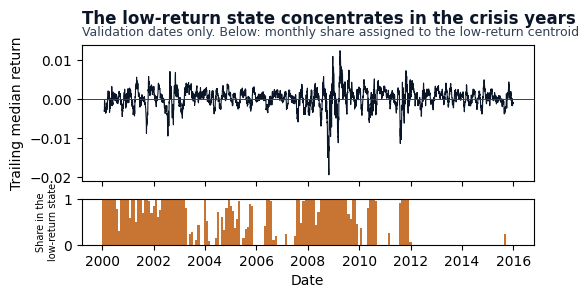

validation dates 3,990, assigned to the low-return centroid 1,861 (47%); mean trailing return -0.00032 in that cluster against +0.00062 in the other
  64 runs, median 4 sessions and longest 291; first assigned 2000-01-28, last 2015-09-21, and the validation window runs to 2015-12-29


In [13]:
_val_spans = [(f["test_start"], f["test_end"], f["fold"]) for f in folds if not f["is_holdout"]]
_val_regime = pl.concat(
    [
        wass_df.filter(
            (pl.col("fold") == fold_idx)
            & (pl.col("timestamp") >= date.fromisoformat(t0))
            & (pl.col("timestamp") < date.fromisoformat(t1))
        )
        for t0, t1, fold_idx in _val_spans
    ]
).sort("timestamp")
_val_ret = xs_stats.join(_val_regime.select("timestamp", "wass_cluster"), on="timestamp").sort(
    "timestamp"
)
_smoothed = _val_ret.select(
    "timestamp",
    pl.col("xs_median_ret").rolling_mean(WASSERSTEIN_WINDOW).alias("trailing"),
    "wass_cluster",
).drop_nulls()

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=FIGSIZE["single_wide"], sharex=True, height_ratios=[3, 1]
)
ax1.plot(_smoothed["timestamp"], _smoothed["trailing"], color=COLORS["blue"], lw=0.8)
ax1.axhline(0, color=COLORS["neutral"], lw=0.7)
ax1.set_ylabel("Trailing median return")
# The assignment goes in its own panel, aggregated to a monthly share. A binary strip over
# sixteen years of daily data gives each session a fraction of a pixel, so isolated assigned
# days vanish entirely and the reader concludes the state stopped when it did not - which is
# what the first draft of this figure showed and what its title then claimed.
_monthly = (
    _smoothed.with_columns(pl.col("timestamp").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg((pl.col("wass_cluster") == 0).mean().alias("share"))
    .sort("month")
)
ax2.fill_between(_monthly["month"], 0, _monthly["share"], color=COLORS["copper"], lw=0, step="mid")
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 1])
ax2.set_ylabel("Share in the\nlow-return state", fontsize=7)
ax2.set_xlabel("Date")
add_message_title(
    ax1,
    "The low-return state concentrates in the crisis years",
    subtitle="Validation dates only. Below: monthly share assigned to the low-return centroid",
)
plt.show()

_shaded = _smoothed.filter(pl.col("wass_cluster") == 0)
_runs = _smoothed.with_columns(
    (pl.col("wass_cluster").diff().fill_null(1) != 0).cum_sum().alias("run")
)
_run_lengths = _runs.filter(pl.col("wass_cluster") == 0).group_by("run").len()["len"]
print(
    f"validation dates {_smoothed.height:,}, assigned to the low-return centroid "
    f"{_shaded.height:,} ({_shaded.height / _smoothed.height:.0%}); mean trailing return "
    f"{_shaded['trailing'].mean():+.5f} in that cluster against "
    f"{_smoothed.filter(pl.col('wass_cluster') == 1)['trailing'].mean():+.5f} in the other"
)
print(
    f"  {_run_lengths.len():,} runs, median {_run_lengths.median():.0f} sessions and longest "
    f"{_run_lengths.max():,}; first assigned {_shaded['timestamp'].min()}, last "
    f"{_shaded['timestamp'].max()}, and the validation window runs to "
    f"{_smoothed['timestamp'].max()}"
)

`wass_dist_ratio` is the second thing the clustering yields: the distance to the nearest
centroid over the distance to the furthest. A window that sits squarely inside one regime
drives it toward zero and a window equidistant from both drives it toward one, so the
feature carries how *certain* the assignment is rather than which regime it picked. That
is the part a momentum model needs, because momentum crashes cluster at the transitions
(Daniel and Moskowitz 2016) rather than inside either state.

Clustering on the median alone reads a shift in the centre of the cross-section and
nothing else. A regime that keeps its median and widens its tails is invisible to it; the
cross-sectional standard deviation, skew and tail quantiles are computed above and left as
diagnostics for exactly that reason.

## 3. Fractional Differencing

A log price is not stationary and a log return has thrown away everything the level knew.
Fractional differencing (Hosking 1981; Lopez de Prado 2018) takes the difference to a
non-integer order $d$, which puts a dial between the two: at $d=0$ the series is the level
and at $d=1$ it is the first difference, and every value in between trades some memory for
some stationarity. `FFD_D` is the equity-class default this notebook uses.

**The default is measured here rather than quoted.** The cell below runs the whole grid
`FFD_D_GRID` on a sample of stocks and reports, for each order, the correlation between
the differenced series and the original log price - how much of the level's memory
is retained - against the share of sampled stocks whose augmented Dickey-Fuller test rejects
a unit root. Those are the two quantities the choice trades off, and neither is knowable
without running it.

**Nothing here is estimated, so nothing is refitted per fold.** The FFD weights are a
closed-form function of $d$ and of the truncation threshold, so the transform is identical
in every fold and carries no estimation window at all. It is computed once and the fold
column is attached during assembly in Section 5. That makes it the useful contrast for the
section either side of it: the hazard this stage is about is *estimation*, not
transformation, and a transform with no parameters has none of it.

In [14]:
def apply_ffd_per_symbol(
    data: pl.DataFrame, d: float = FFD_D, threshold: float = FFD_THRESHOLD
) -> pl.DataFrame:
    """Apply fractional differencing to log prices per symbol.

    Returns DataFrame with (symbol, date, ffd_log_price, ffd_log_volume).
    """
    results = []
    by_symbol = data.sort(["symbol", "timestamp"]).partition_by("symbol", as_dict=True)

    n_success = 0
    n_fail = 0

    for (sym,) in sorted(by_symbol):
        sym_data = by_symbol[(sym,)]

        if len(sym_data) < 100:
            n_fail += 1
            continue

        log_price = sym_data["adj_close"].log()
        # Floor volume at 1 to avoid log(0) = -inf
        log_vol = sym_data["adj_volume"].clip(lower_bound=1).log()

        try:
            ffd_price = ffdiff(log_price, d=d, threshold=threshold)
            ffd_vol = ffdiff(log_vol, d=d, threshold=threshold)

            sym_result = pl.DataFrame(
                {
                    "symbol": [sym] * len(sym_data),
                    "timestamp": sym_data["timestamp"],
                    "ffd_log_price": ffd_price,
                    "ffd_log_volume": ffd_vol,
                }
            ).drop_nulls()

            if len(sym_result) > 0:
                results.append(sym_result)
                n_success += 1
        except Exception:
            n_fail += 1

    print(f"  FFD: {n_success} symbols succeeded, {n_fail} failed/skipped")
    return pl.concat(results) if results else pl.DataFrame()

The sweep below runs on a stratified sample of stocks - every symbol with a long enough
eligible history, taken at a fixed stride so the sample is not the alphabet's first few
hundred names. The augmented Dickey-Fuller test is run per stock per order, and what is
reported is the *share* of stocks rejecting a unit root, because a single stock's test says
very little and the question is whether the order works across the panel.

In [15]:
_ffd_symbols = (
    df.group_by("symbol").len().filter(pl.col("len") >= 2000).sort("symbol")["symbol"].to_list()
)
_ffd_sample = _ffd_symbols[:: max(1, len(_ffd_symbols) // 120)][:120]
_ffd_panel = raw_df.filter(pl.col("symbol").is_in(_ffd_sample)).sort(["symbol", "timestamp"])
_ffd_by_symbol = _ffd_panel.partition_by("symbol", as_dict=True)

grid_rows = []
for d in FFD_D_GRID:
    corrs, rejects = [], []
    for key in sorted(_ffd_by_symbol):
        _lp = _ffd_by_symbol[key]["adj_close"].log().drop_nulls()
        if len(_lp) < 500:
            continue
        _fd = ffdiff(_lp, d=d, threshold=FFD_THRESHOLD)
        _pair = pl.DataFrame({"level": _lp, "ffd": _fd}).drop_nulls()
        if _pair.height < 500 or _pair["ffd"].std() == 0:
            continue
        corrs.append(abs(float(np.corrcoef(_pair["level"], _pair["ffd"])[0, 1])))
        rejects.append(adfuller(_pair["ffd"].to_numpy(), autolag="AIC")[1] < FDR_ALPHA)
    grid_rows.append(
        {
            "d": d,
            "memory": float(np.mean(corrs)),
            "stationary_share": float(np.mean(rejects)),
            "n_symbols": len(corrs),
        }
    )

ffd_grid = pl.DataFrame(grid_rows)
print(f"FFD sweep over {ffd_grid['n_symbols'].max()} sampled stocks")
print(ffd_grid)

FFD sweep over 120 sampled stocks
shape: (8, 4)
┌─────┬──────────┬──────────────────┬───────────┐
│ d   ┆ memory   ┆ stationary_share ┆ n_symbols │
│ --- ┆ ---      ┆ ---              ┆ ---       │
│ f64 ┆ f64      ┆ f64              ┆ i64       │
╞═════╪══════════╪══════════════════╪═══════════╡
│ 0.0 ┆ 1.0      ┆ 0.058333         ┆ 120       │
│ 0.1 ┆ 0.905864 ┆ 0.308333         ┆ 120       │
│ 0.2 ┆ 0.742319 ┆ 0.725            ┆ 120       │
│ 0.3 ┆ 0.595102 ┆ 0.925            ┆ 120       │
│ 0.4 ┆ 0.463579 ┆ 1.0              ┆ 120       │
│ 0.5 ┆ 0.337688 ┆ 1.0              ┆ 120       │
│ 0.7 ┆ 0.142635 ┆ 1.0              ┆ 120       │
│ 1.0 ┆ 0.014823 ┆ 1.0              ┆ 120       │
└─────┴──────────┴──────────────────┴───────────┘


The two curves cross, and where they cross is the whole argument for a fractional order.
Memory falls with $d$ and the share of stocks that pass the stationarity test rises with
it; the first difference sits at the right-hand end, stationary and remembering nothing of
the level.

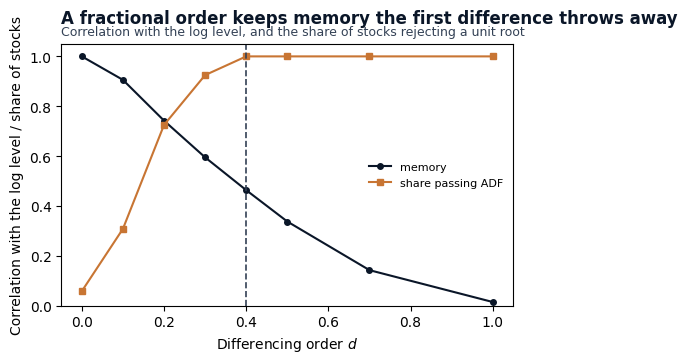

at d=0.4: memory 0.464, 100.0% of 120 sampled stocks reject a unit root | at d=1.0: memory 0.015, 100.0%
  the weight vector at d=0.4 truncates at 1458 lags


In [16]:
_chosen = ffd_grid.filter(pl.col("d") == FFD_D).row(0, named=True)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(ffd_grid["d"], ffd_grid["memory"], color=COLORS["blue"], marker="o", ms=4, label="memory")
ax.plot(
    ffd_grid["d"],
    ffd_grid["stationary_share"],
    color=COLORS["copper"],
    marker="s",
    ms=4,
    label="share passing ADF",
)
ax.axvline(FFD_D, color=COLORS["neutral"], ls="--", lw=1.2)
ax.set_xlabel("Differencing order $d$")
ax.set_ylabel("Correlation with the log level / share of stocks")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=8, loc="center right")
add_message_title(
    ax,
    "A fractional order keeps memory the first difference throws away",
    subtitle="Correlation with the log level, and the share of stocks rejecting a unit root",
)
plt.show()

print(
    f"at d={FFD_D}: memory {_chosen['memory']:.3f}, {_chosen['stationary_share']:.1%} of "
    f"{_chosen['n_symbols']} sampled stocks reject a unit root | "
    f"at d={ffd_grid['d'].max()}: memory "
    f"{ffd_grid.filter(pl.col('d') == ffd_grid['d'].max())['memory'][0]:.3f}, "
    f"{ffd_grid.filter(pl.col('d') == ffd_grid['d'].max())['stationary_share'][0]:.1%}"
)
print(
    f"  the weight vector at d={FFD_D} truncates at "
    f"{len(get_ffd_weights(FFD_D, threshold=FFD_THRESHOLD))} lags"
)

### Apply the transform to the panel

On the complete price series per stock, for the reason Section 1 states: the weight vector
reaches back hundreds of sessions, and on the screened frame those would be eligible rows
rather than sessions.

In [17]:
print("Computing fractional differencing features...")
ffd_df = apply_ffd_per_symbol(raw_df)
print(f"FFD features: {len(ffd_df):,} rows, {ffd_df['symbol'].n_unique()} symbols")

Computing fractional differencing features...


  FFD: 3193 symbols succeeded, 6 failed/skipped


FFD features: 14,498,683 rows, 3193 symbols


## 4. Per-Fold GARCH Conditional Volatility

This is the section the stage is really about. A GARCH conditional volatility is not a
function of a stock's past returns alone - it is a function of $(\omega, \alpha, \beta)$,
and those come from a maximum-likelihood fit over some window. Fit them once over
everything and every row's volatility knows the whole sample. So per fold:

1. Rank the eligible stocks of the training window by liquidity and take the top
   `GARCH_TOP_N`, because a fit on a thin name is unstable and the choice of *which* stocks
   to fit is itself an estimate that must not read past the boundary.
2. Fit GARCH(1,1) by maximum likelihood on that fold's training returns, per symbol.
3. Run the variance recursion forward over training and validation with `model.fix()`,
   which applies the fitted parameters without re-estimating them. This is the distinction
   between filtered and smoothed inference: the volatility at $t$ is built from returns up
   to $t$ and parameters from before the training window closed, never from later bars.

Stocks outside the subsample take a market-level GARCH fitted the same way on the
cross-sectional median return, so every emitted row carries a conditional volatility.

The returns handed to both fits come from the **complete** per-symbol series. A variance
recursion reads its input in order and treats consecutive elements as consecutive sessions;
feeding it the eligible rows only would splice the two sides of an ineligible spell
together and price the jump across it as one day's move.

In [18]:
def select_garch_subsample(data: pl.DataFrame, top_n: int) -> list[str]:
    """Select top-N most liquid symbols by median ADV."""
    ranking = (
        data.group_by("symbol")
        .agg(
            pl.col("adv_21d").median().alias("median_adv"),
            pl.len().alias("n_obs"),
        )
        .filter(pl.col("n_obs") >= GARCH_MIN_OBS)
        .sort("median_adv", descending=True)
        .head(top_n)
    )
    return ranking["symbol"].to_list()

In [19]:
def fit_garch_per_fold(
    by_symbol: dict,
    fold: dict,
    symbols: list[str],
) -> tuple[pl.DataFrame, list[dict]]:
    """Fit GARCH(1,1) per symbol for a single fold.

    Fit on training data, use model.fix() for the full train+validation period.
    Returns the feature frame and the fitted parameters, one row per symbol.
    """
    fold_idx = fold["fold"]
    results = []
    params_rows = []
    n_success = 0
    n_fail = 0

    for sym in symbols:
        sym_data = by_symbol.get((sym,))
        if sym_data is None:
            n_fail += 1
            continue
        sym_data = sym_data.filter(pl.col("returns").is_not_null())

        # Training data for parameter estimation
        train_data = sym_data.filter(
            (pl.col("timestamp").cast(pl.Utf8) >= fold["train_start"])
            & (pl.col("timestamp").cast(pl.Utf8) < fold["train_end"])
        )

        if len(train_data) < GARCH_MIN_OBS:
            n_fail += 1
            continue

        train_returns_pct = (train_data["returns"] * 100).to_numpy()

        try:
            # Fit on training data only
            train_model = arch_model(
                train_returns_pct,
                mean="Constant",
                vol="GARCH",
                p=1,
                q=1,
                dist="Normal",
            )
            train_result = train_model.fit(disp="off", show_warning=False)
            fitted_params = train_result.params
            params_rows.append(
                {
                    "fold": fold_idx,
                    "symbol": sym,
                    "omega": float(fitted_params["omega"]),
                    "alpha": float(fitted_params["alpha[1]"]),
                    "beta": float(fitted_params["beta[1]"]),
                }
            )

            # Full train+test period for feature extraction
            full_data = sym_data.filter(
                (pl.col("timestamp").cast(pl.Utf8) >= fold["train_start"])
                & (pl.col("timestamp").cast(pl.Utf8) < fold["test_end"])
            )
            full_returns_pct = (full_data["returns"] * 100).to_numpy()

            # Run variance recursion with frozen parameters (no re-estimation)
            full_model = arch_model(
                full_returns_pct,
                mean="Constant",
                vol="GARCH",
                p=1,
                q=1,
                dist="Normal",
            )
            fixed_result = full_model.fix(fitted_params)
            cond_vol = fixed_result.conditional_volatility

            # Annualized conditional vol (input is in % daily)
            cond_vol_ann = cond_vol * np.sqrt(252) / 100  # Back to decimal

            sym_result = pl.DataFrame(
                {
                    "symbol": [sym] * len(full_data),
                    "timestamp": full_data["timestamp"].to_list(),
                    "garch_cond_vol": cond_vol_ann,
                    "fold": [fold_idx] * len(full_data),
                }
            ).drop_nulls()

            if len(sym_result) > 0:
                results.append(sym_result)
                n_success += 1
        except Exception:
            n_fail += 1

    tag = " [HOLDOUT]" if fold.get("is_holdout", False) else ""
    print(f"  Fold {fold_idx}{tag} GARCH: {n_success}/{len(symbols)} fitted, {n_fail} failed")
    return (pl.concat(results) if results else pl.DataFrame()), params_rows

In [20]:
def fit_market_garch_per_fold(
    market_ret: FloatArray,
    dates_list: list,
    fold: dict,
) -> pl.DataFrame:
    """Fit market-level GARCH for one fold, return (timestamp, mkt_garch_vol, fold)."""
    fold_idx = fold["fold"]

    # Build date-indexed arrays
    train_mask = [
        (str(d) >= fold["train_start"] and str(d) < fold["train_end"]) for d in dates_list
    ]
    full_mask = [(str(d) >= fold["train_start"] and str(d) < fold["test_end"]) for d in dates_list]

    train_indices = [i for i, m in enumerate(train_mask) if m]
    full_indices = [i for i, m in enumerate(full_mask) if m]

    if len(train_indices) < GARCH_MIN_OBS:
        return pl.DataFrame()

    train_ret_pct = market_ret[train_indices] * 100
    train_ret_clean = train_ret_pct[~np.isnan(train_ret_pct)]

    if len(train_ret_clean) < GARCH_MIN_OBS:
        return pl.DataFrame()

    try:
        train_model = arch_model(
            train_ret_clean,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            dist="Normal",
        )
        train_result = train_model.fit(disp="off", show_warning=False)
        fitted_params = train_result.params

        # Full period with frozen params
        full_ret_pct = market_ret[full_indices] * 100
        # Remove NaN for model fitting but track indices
        valid_mask = ~np.isnan(full_ret_pct)
        full_ret_clean = full_ret_pct[valid_mask]
        valid_dates = [dates_list[full_indices[i]] for i, v in enumerate(valid_mask) if v]

        full_model = arch_model(
            full_ret_clean,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            dist="Normal",
        )
        fixed_result = full_model.fix(fitted_params)
        mkt_cond_vol = fixed_result.conditional_volatility * np.sqrt(252) / 100

        return pl.DataFrame(
            {
                "timestamp": valid_dates[: len(mkt_cond_vol)],
                "mkt_garch_vol": mkt_cond_vol,
                "fold": [fold_idx] * len(mkt_cond_vol),
            }
        )
    except Exception as e:
        print(f"  Fold {fold_idx} market GARCH failed: {e}")
        return pl.DataFrame()

In [21]:
print("Per-fold GARCH fitting...")

# The recursion reads the complete per-symbol series; the eligible frame decides only which
# stocks are liquid enough to be worth fitting. Partitioned once, outside the fold loop.
_returns_by_symbol = raw_df.select("symbol", "timestamp", "returns").partition_by(
    "symbol", as_dict=True
)

garch_all_folds = []
mkt_garch_all_folds = []
garch_param_rows = []

for fold in folds:
    # Select subsample by liquidity inside the training window, on the eligible frame
    train_data = df.filter(
        (pl.col("timestamp").cast(pl.Utf8) >= fold["train_start"])
        & (pl.col("timestamp").cast(pl.Utf8) < fold["train_end"])
    )
    garch_symbols = select_garch_subsample(train_data, GARCH_TOP_N)

    fold_garch, fold_params = fit_garch_per_fold(_returns_by_symbol, fold, garch_symbols)
    if len(fold_garch) > 0:
        garch_all_folds.append(fold_garch)
    garch_param_rows.extend(fold_params)

    # Market-level GARCH fallback
    fold_mkt = fit_market_garch_per_fold(market_ret, dates, fold)
    if len(fold_mkt) > 0:
        mkt_garch_all_folds.append(fold_mkt)

garch_df = pl.concat(garch_all_folds) if garch_all_folds else pl.DataFrame()
mkt_garch_df = pl.concat(mkt_garch_all_folds) if mkt_garch_all_folds else pl.DataFrame()
garch_params = pl.DataFrame(garch_param_rows)

if len(garch_df) > 0:
    print(
        f"\nGARCH features: {len(garch_df):,} rows, {garch_df['symbol'].n_unique()} symbols, {garch_df['fold'].n_unique()} folds"
    )
if len(mkt_garch_df) > 0:
    print(
        f"Market GARCH: {len(mkt_garch_df):,} rows across {mkt_garch_df['fold'].n_unique()} folds"
    )

Per-fold GARCH fitting...


  Fold 0 GARCH: 200/200 fitted, 0 failed


  Fold 1 GARCH: 200/200 fitted, 0 failed


  Fold 2 GARCH: 200/200 fitted, 0 failed


  Fold 3 GARCH: 200/200 fitted, 0 failed


...

  Fold 12 GARCH: 200/200 fitted, 0 failed


  Fold 13 GARCH: 200/200 fitted, 0 failed


  Fold 14 GARCH: 200/200 fitted, 0 failed


  Fold 15 GARCH: 200/200 fitted, 0 failed


  Fold 16 [HOLDOUT] GARCH: 200/200 fitted, 0 failed

GARCH features: 9,307,205 rows, 389 symbols, 17 folds
Market GARCH: 51,272 rows across 17 folds


## 4b. Fit stability across folds

Refitting each fold costs a fit per symbol per fold, and the question it raises is whether
the parameters move enough to be worth it. Two of the three transforms have parameters to
track: the GARCH persistence $\alpha + \beta$, which says how long a volatility shock takes
to decay, and the separation between the two Wasserstein centroids, which says how far
apart the two regimes the clustering found actually are. FFD has none, by construction.

A parameter path that is flat says per-fold refitting bought nothing and one fit would have
served; a path that swings says the transform is chasing a moving target, and the reader
should carry that into how much weight the feature deserves. The refit cadence here is one
fit per fold with nothing updating between refits, and that is what the figure judges.

The two answers differ, which is the point of measuring rather than assuming. The prints
below give both ranges, and the spread of the GARCH band matters separately from the
position of its median: a median that repeats while the interquartile band widens says the
typical stock's volatility dynamics are stable and the tails of the subsample are not.

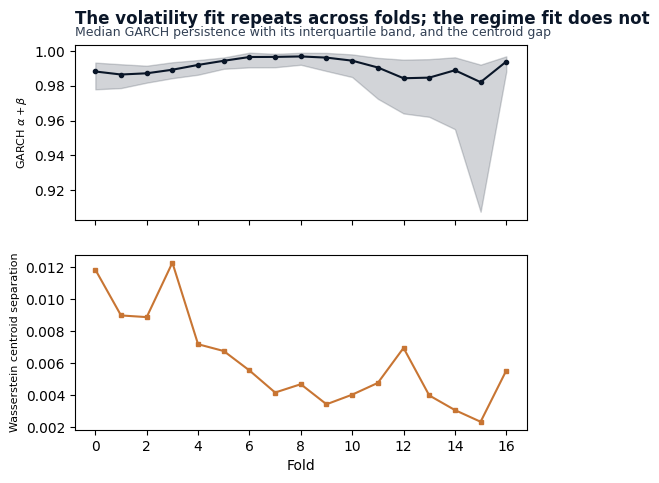

GARCH persistence: median per fold from 0.9820 to 0.9968 over 17 folds
Wasserstein centroid separation: 0.00233 to 0.01229


In [22]:
_persistence = (
    garch_params.with_columns((pl.col("alpha") + pl.col("beta")).alias("persistence"))
    .group_by("fold")
    .agg(
        pl.col("persistence").median().alias("median"),
        pl.col("persistence").quantile(0.25).alias("q25"),
        pl.col("persistence").quantile(0.75).alias("q75"),
    )
    .sort("fold")
)
_centroids = pl.DataFrame(wass_centroid_rows).sort("fold")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True)
ax1.plot(_persistence["fold"], _persistence["median"], color=COLORS["blue"], marker="o", ms=3)
ax1.fill_between(
    _persistence["fold"],
    _persistence["q25"],
    _persistence["q75"],
    color=COLORS["blue"],
    alpha=0.18,
)
ax1.set_ylabel(r"GARCH $\alpha+\beta$", fontsize=8)
ax2.plot(
    _centroids["fold"], _centroids["centroid_separation"], color=COLORS["copper"], marker="s", ms=3
)
ax2.set_ylabel("Wasserstein centroid separation", fontsize=8)
ax2.set_xlabel("Fold")
add_message_title(
    ax1,
    "The volatility fit repeats across folds; the regime fit does not",
    subtitle="Median GARCH persistence with its interquartile band, and the centroid gap",
)
plt.show()

print(
    f"GARCH persistence: median per fold from {_persistence['median'].min():.4f} to "
    f"{_persistence['median'].max():.4f} over {_persistence.height} folds"
)
print(
    f"Wasserstein centroid separation: {_centroids['centroid_separation'].min():.5f} to "
    f"{_centroids['centroid_separation'].max():.5f}"
)

## 5. Assemble Temporal Features

Merge all temporal features per fold. The fold column is the primary
organizing key: GARCH and Wasserstein features carry fold from their
per-fold fitting; FFD (deterministic, no parameters) is replicated
across folds during the join.

In [23]:
# Build per-fold feature panels
# GARCH has fold column already; it's the base for per-fold assembly
# Wasserstein has fold column; it's market-level, broadcast to all symbols
# FFD has no fold column (deterministic); joined by (symbol, timestamp)

temporal_frames = []

fold_ids = sorted(set(f["fold"] for f in folds))

for fold_idx in fold_ids:
    fold_info = next(f for f in folds if f["fold"] == fold_idx)

    # Build (symbol, timestamp) skeleton for this fold's full period
    fold_skeleton = (
        df.filter(
            (pl.col("timestamp").cast(pl.Utf8) >= fold_info["train_start"])
            & (pl.col("timestamp").cast(pl.Utf8) < fold_info["test_end"])
        )
        .select(["symbol", "timestamp"])
        .unique()
        .with_columns(pl.lit(fold_idx).alias("fold"))
    )

    # Join Wasserstein features (market-level, broadcast to all stocks)
    if len(wass_df) > 0:
        wass_fold = wass_df.filter(pl.col("fold") == fold_idx).drop("fold")
        fold_skeleton = fold_skeleton.join(wass_fold, on="timestamp", how="left")

    # Join FFD features (per-stock, no fold column needed)
    if len(ffd_df) > 0:
        fold_skeleton = fold_skeleton.join(ffd_df, on=["symbol", "timestamp"], how="left")

    # Join per-stock GARCH
    if len(garch_df) > 0:
        garch_fold = garch_df.filter(pl.col("fold") == fold_idx).drop("fold")
        fold_skeleton = fold_skeleton.join(garch_fold, on=["symbol", "timestamp"], how="left")

    # Join market GARCH (broadcast to all stocks)
    if len(mkt_garch_df) > 0:
        mkt_fold = mkt_garch_df.filter(pl.col("fold") == fold_idx).drop("fold")
        fold_skeleton = fold_skeleton.join(mkt_fold, on="timestamp", how="left")

    # For stocks without per-stock GARCH, fill with market GARCH
    if "garch_cond_vol" in fold_skeleton.columns and "mkt_garch_vol" in fold_skeleton.columns:
        fold_skeleton = fold_skeleton.with_columns(
            pl.when(pl.col("garch_cond_vol").is_null())
            .then(pl.col("mkt_garch_vol"))
            .otherwise(pl.col("garch_cond_vol"))
            .alias("garch_cond_vol")
        )

    temporal_frames.append(fold_skeleton)

temporal = pl.concat(temporal_frames).sort(["fold", "symbol", "timestamp"])

# Drop rows with no temporal features at all
temporal = temporal.drop_nulls(subset=["symbol", "timestamp"])

temporal_feature_cols = [c for c in temporal.columns if c not in ("symbol", "timestamp", "fold")]
n_temporal_features = len(temporal_feature_cols)

# A missing value is a null. `ffdiff` returns a float NaN where the log price it is handed
# is not finite, and Polars does not treat that as null: `drop_nulls` keeps it, and every
# summary that reaches it returns NaN rather than skipping the row - including the one
# printed immediately below, which is why the conversion happens before it and not at the
# write. 03_financial_features Section 7 converts the oscillators' NaN for the same reason.
_nan_carriers = {
    c: int(temporal[c].is_nan().sum())
    for c in temporal_feature_cols
    if temporal.schema[c] in (pl.Float32, pl.Float64) and temporal[c].is_nan().any()
}
if _nan_carriers:
    temporal = temporal.with_columns(pl.col(c).fill_nan(None) for c in _nan_carriers)
print(
    f"NaN converted to null in {len(_nan_carriers)} of {n_temporal_features} features, "
    f"{sum(_nan_carriers.values()):,} values: {sorted(_nan_carriers)}"
)

print(f"\nTemporal features: {n_temporal_features} features")
print(f"  Rows: {len(temporal):,}")
print(f"  Symbols: {temporal['symbol'].n_unique()}")
print(f"  Folds: {temporal['fold'].n_unique()}")

# Feature summary (exclude fold from summary)
for col in temporal_feature_cols:
    valid = temporal[col].drop_nulls()
    if len(valid) > 0:
        print(f"  {col}: {len(valid):,} valid (mean={valid.mean():.6f}, std={valid.std():.4f})")

NaN converted to null in 1 of 9 features, 16,710 values: ['ffd_log_price']

Temporal features: 9 features
  Rows: 68,721,929


  Symbols: 3178
  Folds: 17


  wass_cluster: 68,709,078 valid (mean=0.663454, std=0.4725)
  wass_dist_min: 68,709,078 valid (mean=0.003137, std=0.0034)


  wass_dist_max: 68,709,078 valid (mean=0.007425, std=0.0047)
  wass_dist_ratio: 68,709,078 valid (mean=0.449860, std=0.2405)


  wass_tail_div: 68,709,078 valid (mean=-0.000159, std=0.0039)


  ffd_log_price: 68,705,002 valid (mean=0.133740, std=0.0806)
  ffd_log_volume: 68,721,712 valid (mean=0.557969, std=0.5594)


  garch_cond_vol: 68,721,893 valid (mean=0.199187, std=0.1454)
  mkt_garch_vol: 68,721,892 valid (mean=0.168160, std=0.0934)


## 6. Save Temporal Features

The panel key is `(symbol, timestamp, fold)`, not `(symbol, timestamp)`: the same
symbol-date appears once per fold whose span covers it, carrying that fold's fit. A
downstream join that forgets the fold column would multiply rows silently, so the
uniqueness of the three-column key is asserted before the write rather than trusted.

The schema is frozen against the columns each transform declared it would emit, and the
file is written with a digest sidecar recording the content hash of the values, the row
count, the key columns, the notebook that wrote them, and the digest of the price panel
they were built from - the same record [`02_labels`](02_labels.ipynb) and
[`03_financial_features`](03_financial_features.ipynb) write, so a stage that reads this
file can check it was built from the same download it was.

In [24]:
EMITTED_FEATURES = [
    "wass_cluster",
    "wass_dist_min",
    "wass_dist_max",
    "wass_dist_ratio",
    "wass_tail_div",
    "ffd_log_price",
    "ffd_log_volume",
    "garch_cond_vol",
    "mkt_garch_vol",
]
assert sorted(temporal_feature_cols) == sorted(EMITTED_FEATURES), (
    f"emitted {sorted(temporal_feature_cols)} against declared {sorted(EMITTED_FEATURES)}"
)

# No NaN reaches the artifact. Converted in Section 5, checked here.
_still_nan = [
    c
    for c in temporal_feature_cols
    if temporal.schema[c] in (pl.Float32, pl.Float64) and temporal[c].is_nan().any()
]
assert not _still_nan, f"features reaching the artifact with NaN: {_still_nan}"

_key = ["symbol", "timestamp", "fold"]
assert temporal.select(_key).n_unique() == temporal.height, (
    f"{temporal.height - temporal.select(_key).n_unique()} duplicate rows on {_key}"
)

# The emitted frame reconciles against the eligible frame it was built from: every emitted
# symbol-date is one this stage's screen kept, and no fold emits a row outside its own span.
_eligible_keys = df.select("symbol", "timestamp").unique()
assert temporal.join(_eligible_keys, on=["symbol", "timestamp"], how="anti").height == 0, (
    "the emitted panel carries symbol-dates the eligibility screen removed"
)

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
output_path = FEATURES_DIR / "model_based.parquet"
record = write_artifact(
    temporal,
    output_path,
    keys=_key,
    written_by="04_model_based_features",
    inputs={"market_data": MARKET_DATA_DIGEST},
)
print(f"Saved {n_temporal_features} features to {display_path(output_path)}")
print(f"model_based.parquet: {record['n_rows']:,} rows, digest {record['digest']}")
print(f"  Folds: {sorted(temporal['fold'].unique().to_list())}")

Saved 9 features to case_studies/us_equities_panel/features/model_based.parquet
model_based.parquet: 68,721,929 rows, digest fb726c79484ee149
  Folds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


## 7. Incremental IC Evaluation

One question: does a fitted feature carry anything against the primary label that the
stage-03 matrix did not? It is asked, not answered with a selection - which features to
keep is [`05_evaluation`](05_evaluation.ipynb)'s decision, and this section selects
nothing.

**Validation rows only.** Each fold's training bars are the bars its parameters came from,
so scoring them measures the fit rather than the feature. The frame below is the union of
the CV folds' validation spans, each row taken from the fold whose validation window
covers it, and the holdout fold contributes nothing.

**Sealed on the label's endpoint, not the observation date.** A row observed on the last
validation session of the last CV fold resolves `LABEL_HORIZON` sessions later, and if that
lands on or after `holdout_start` the row has read a holdout outcome. The usable boundary
is therefore the last session whose forward window closes before the holdout opens, which
is derived below from the panel's own calendar rather than typed.

**Chronologically ordered.** `cross_sectional_ic_series` sorts the dates it returns.
Feeding a Newey-West correction a series assembled in partition-scan order computes the
lag structure over an arbitrary permutation of time, and the resulting standard error is
not merely wrong but unstable between runs.

**Two corrections, kept apart.** Newey-West prices the IC series' own persistence into each
feature's t-statistic; Benjamini-Hochberg prices the fact that several features are tested
at once. Neither substitutes for the other.

**And only the features a cross-sectional statistic can measure.** Most of what this
notebook emits is market-level: the Wasserstein features describe the panel's centre on a
date, and `mkt_garch_vol` describes its volatility, so every stock carries the same value
on that date. An information coefficient is a correlation *across* the cross-section, and a
column with no cross-sectional variation has no correlation with anything in it - not a
small one, an undefined one. Scoring such a column here returns a number, and the number is
an artifact of how the tie is broken rather than a statement about the feature. The cell
below classifies the emitted columns by counting distinct values within a date and scores
only those that vary, and the ones it sets aside are set aside by measurement rather than
by a list somebody kept up to date.

Setting them aside says nothing about their worth. A daily regime state can matter to a
cross-sectional ranker through what it interacts with - momentum conditioned on the regime
is a different signal from momentum - and it can matter to a timing overlay. Both are
questions about a fitted model, so both belong downstream; neither is answerable with the
statistic this section computes.

In [25]:
_label_df = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
label_col = PRIMARY_LABEL

# The endpoint of the label is the LABEL_HORIZON-th next session in the stock's own series,
# derived on the complete price frame: shifting the screened frame would return the next
# *eligible* session, which is a later date and depends on eligibility after the decision.
_label_end = raw_df.select(
    "symbol",
    "timestamp",
    pl.col("timestamp").shift(-LABEL_HORIZON).over("symbol").alias("_label_end"),
)

# Validation spans of the CV folds only - never the training bars, never the holdout fold.
_val_frames = [
    temporal.filter(
        (pl.col("fold") == f["fold"])
        & (pl.col("timestamp") >= date.fromisoformat(f["test_start"]))
        & (pl.col("timestamp") < date.fromisoformat(f["test_end"]))
    )
    for f in folds
    if not f["is_holdout"]
]
_val_rows = pl.concat(_val_frames)
# The validation windows tile the development period without overlapping, so a symbol-date
# reaches the scored frame from exactly one fold. If they ever overlapped, the IC helper's
# self-join would multiply the cross-section instead of raising.
assert _val_rows.select("symbol", "timestamp").n_unique() == _val_rows.height, (
    "a symbol-date appears in more than one fold's validation window"
)

eval_df = (
    _val_rows.join(_label_df, on=["symbol", "timestamp"], how="inner")
    .join(_label_end, on=["symbol", "timestamp"], how="left")
    .filter(pl.col("_label_end") < date.fromisoformat(holdout_start))
    .drop("_label_end")
)
assert eval_df["timestamp"].max() < date.fromisoformat(holdout_start), (
    "a scored row resolves inside the holdout"
)
_train_spans = [
    (date.fromisoformat(f["train_start"]), date.fromisoformat(f["train_end"]), f["fold"])
    for f in folds
]
for t0, t1, fold_idx in _train_spans:
    _bled = eval_df.filter(
        (pl.col("fold") == fold_idx) & (pl.col("timestamp") >= t0) & (pl.col("timestamp") < t1)
    )
    assert _bled.height == 0, f"{_bled.height} scored rows sit inside fold {fold_idx}'s own fit"

print(f"Scoring {len(temporal_feature_cols)} temporal features against {label_col}")
print(
    f"  validation rows {eval_df.height:,} over {eval_df['timestamp'].n_unique():,} dates, "
    f"through {eval_df['timestamp'].max()}, holdout opens {holdout_start}"
)

# The minimum cross-section is half the median, as in 02_labels Section G, rather than a
# fixed count: a rank correlation over a handful of names is mostly noise, and a bare
# threshold means something different on a panel of a hundred names than on one of a
# thousand.
_min_obs = int(eval_df.group_by("timestamp").len()["len"].median() // 2)
print(f"  minimum cross-section {_min_obs:,} stocks")

Scoring 9 temporal features against fwd_ret_1d
  validation rows 7,142,754 over 4,015 dates, through 2015-12-29, holdout opens 2016-01-01
  minimum cross-section 915 stocks


Which columns vary across a cross-section is measured, not declared. A feature whose
median date carries a single distinct value is market-level and is set aside; the count
for each is printed, so a column that is *nearly* constant - one value for the stocks a
model was fitted on and a broadcast for the rest - is visible as the partial thing it is
rather than passing as cross-sectional.

In [26]:
_variation = (
    eval_df.group_by("timestamp")
    .agg(pl.col(c).n_unique().alias(c) for c in temporal_feature_cols)
    .select(pl.col(c).median().alias(c) for c in temporal_feature_cols)
    .row(0, named=True)
)
CROSS_SECTIONAL = [c for c in temporal_feature_cols if _variation[c] > 1]
MARKET_LEVEL = [c for c in temporal_feature_cols if _variation[c] <= 1]

print("distinct values in the median date's cross-section:")
for c in temporal_feature_cols:
    kind = "cross-sectional" if _variation[c] > 1 else "market-level, not scored below"
    print(f"  {c:18s} {int(_variation[c]):>6,}   {kind}")
assert CROSS_SECTIONAL, "no emitted feature varies across the cross-section"

distinct values in the median date's cross-section:
  wass_cluster            1   market-level, not scored below
  wass_dist_min           1   market-level, not scored below
  wass_dist_max           1   market-level, not scored below
  wass_dist_ratio         1   market-level, not scored below
  wass_tail_div           1   market-level, not scored below
  ffd_log_price       1,830   cross-sectional
  ffd_log_volume      1,821   cross-sectional
  garch_cond_vol        197   cross-sectional
  mkt_garch_vol           1   market-level, not scored below


In [27]:
ic_rows = []
for feat in CROSS_SECTIONAL:
    _ic = cross_sectional_ic_series(
        eval_df,
        eval_df,
        pred_col=feat,
        ret_col=label_col,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=_min_obs,
    ).drop_nulls("ic")
    if _ic.height < 20:
        continue
    stats = compute_ic_hac_stats(_ic, ic_col="ic", label_horizon=LABEL_HORIZON)
    ic_rows.append(
        {
            "feature": feat,
            "n_dates": _ic.height,
            "ic_mean": stats["mean_ic"],
            "hac_se": stats["hac_se"],
            "hac_tstat": stats["t_stat"],
            "p_value": stats["p_value"],
        }
    )

temporal_ic = pl.DataFrame(ic_rows)
assert temporal_ic.height > 0, "no temporal feature carried enough scored dates to compute an IC"

_fdr = benjamini_hochberg_fdr(
    temporal_ic["p_value"].to_list(), alpha=FDR_ALPHA, return_details=True
)
temporal_ic = temporal_ic.with_columns(
    pl.Series("adjusted_p", list(_fdr["adjusted_p_values"])),
    pl.Series("significant_fdr05", list(_fdr["rejected"])),
).sort(pl.col("ic_mean").abs(), descending=True)

print(
    f"features tested {temporal_ic.height} of {len(temporal_feature_cols)} emitted "
    f"({len(MARKET_LEVEL)} set aside as market-level), nominally significant "
    f"{int((temporal_ic['p_value'] < FDR_ALPHA).sum())}, rejected under Benjamini-Hochberg "
    f"{int(_fdr['n_rejected'])}"
)
print(temporal_ic.select("feature", "n_dates", "ic_mean", "hac_tstat", "significant_fdr05"))

features tested 3 of 9 emitted (6 set aside as market-level), nominally significant 3, rejected under Benjamini-Hochberg 3
shape: (3, 5)
┌────────────────┬─────────┬───────────┬───────────┬───────────────────┐
│ feature        ┆ n_dates ┆ ic_mean   ┆ hac_tstat ┆ significant_fdr05 │
│ ---            ┆ ---     ┆ ---       ┆ ---       ┆ ---               │
│ str            ┆ i64     ┆ f64       ┆ f64       ┆ bool              │
╞════════════════╪═════════╪═══════════╪═══════════╪═══════════════════╡
│ ffd_log_volume ┆ 4010    ┆ 0.014681  ┆ 16.679062 ┆ true              │
│ ffd_log_price  ┆ 4010    ┆ -0.012986 ┆ -5.773266 ┆ true              │
│ garch_cond_vol ┆ 4010    ┆ -0.002329 ┆ -2.070314 ┆ true              │
└────────────────┴─────────┴───────────┴───────────┴───────────────────┘


The bars are signed, because a feature the panel ranks one way and a feature it ranks the
other are different signals and a sorted magnitude hides that. The interval is
$\pm2$ HAC standard errors, and colour marks whether Benjamini-Hochberg still rejects the
null for that feature. Only the columns that vary across a cross-section appear; the
subtitle names how many were set aside, and the comparison against the stage-03 features is
deferred to [`05_evaluation`](05_evaluation.ipynb), which scores both matrices on one frame.

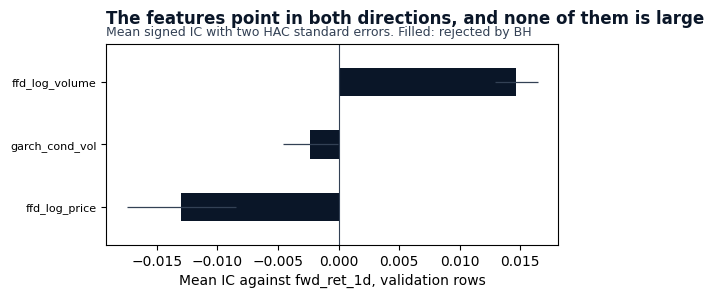

In [28]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
_order = temporal_ic.sort("ic_mean")
_ypos = np.arange(_order.height)
ax.barh(
    _ypos,
    _order["ic_mean"],
    xerr=2 * _order["hac_se"].to_numpy(),
    color=[
        COLORS["blue"] if s else COLORS["silver_muted"]
        for s in _order["significant_fdr05"].to_list()
    ],
    error_kw=dict(ecolor=COLORS["neutral"], lw=0.9),
    height=0.45,
)
ax.set_yticks(_ypos)
ax.set_yticklabels(_order["feature"].to_list(), fontsize=8)
ax.set_ylim(-0.6, _order.height - 0.4)
ax.axvline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel(f"Mean IC against {label_col}, validation rows")
add_message_title(
    ax,
    "The features point in both directions, and none of them is large",
    subtitle="Mean signed IC with two HAC standard errors. Filled: rejected by BH",
)
plt.show()

## Key Takeaways

1. **A fitted feature carries its estimation window, so resolve the folds before anything
   is fitted.** Every parameter here comes from one fold's training bars, and the assertion
   after the fold table is what establishes that rather than the prose around it. A
   notebook that resolves its boundaries after the fit has nothing left to check them
   against.
2. **Run inference forward, never backward.** `model.fix()` applies training parameters to
   later returns without re-estimating them, so a row's conditional volatility is built
   from returns up to that row. The smoothed alternative - refitting or running a smoother
   over the whole span - conditions every value on the end of the series, and it fails
   silently because the output looks the same.
3. **Emit the holdout fold, and say why that is allowed.** These transforms read prices and
   never labels, so a pre-holdout fit may produce filtered values *for* holdout dates and
   the model stages need them. What is forbidden is a fit that reads a holdout bar.
4. **Measure the trade a default encodes.** The differencing order is not searched per fold
   and does not have to be, but the memory it keeps and the stationarity it buys are
   measurable in a few lines and were worth measuring rather than quoting.
5. **Score the increment on validation rows, in time order.** Training rows measure the
   fit, not the feature; a per-date IC series in partition order gives a Newey-West
   standard error computed over a permutation of time; and the multiplicity correction is a
   separate quantity from the autocorrelation one.
6. **Check that the statistic can reach the feature before reporting it.** Most of what a
   market-level transform emits is constant within a date, and a cross-sectional
   correlation against a constant is undefined rather than zero. The helper will still
   return a number - here it returned the same number for every one of them - so the
   classification is measured from the data and the columns it cannot reach are named and
   set aside instead of ranked.

### Known limitations

- Six of the nine emitted columns are market-level and carry no cross-sectional
  information as main effects. They are emitted because a model can use them through an
  interaction or a timing overlay, and neither is tested here.
- The GARCH subsample is the most liquid stocks of each training window. Every other stock
  carries the market-level conditional volatility, so `garch_cond_vol` varies across a few
  hundred names and is a broadcast for the rest - its IC is measured on that mostly
  degenerate column, and the distinct-value count printed above is what says so.
- Clustering on the cross-sectional median reads a shift in the centre of the panel and is
  blind to a regime that keeps its centre and widens its tails.
- The refit cadence is one fit per fold with nothing updating between refits. The fit
  stability figure says what that costs; choosing a different cadence is not attempted here.
- `arch`'s `.fix()` recomputes its internal variance bounds over the series it is handed,
  which spans training and validation. The clipping envelope therefore depends on the
  validation period even though the parameters do not.

**Next**: [`05_evaluation`](05_evaluation.ipynb) scores this matrix and the stage-03 one on
the same frame and decides what carries forward.